# Task 3 — Multi-Agent Financial Research System (LangGraph)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nazifmhd/Task-1---Financial-AI/blob/main/task3_agentic/task3_agentic.ipynb)

| Part | What this notebook shows |
|---|---|
| 3A | Five custom tools. A ReAct agent picks tools **autonomously** with visible *action → observation → replan* steps, writes a validated three-section report, and recovers from tool failures (injected outage, fake ticker). |
| 3B | Data Analyst (A) and Research Writer (B) with **structurally enforced** tool access, Pydantic handoffs, a full message trace, and a critique loop (B → A → B). |
| 3C | Short-term memory (follow-up answered with **zero** new tool calls), a persistent per-ticker cache (second run = cache hit), and `logs/agent_trace.jsonl`. |
| Bonus | Streamlit dashboard over the trace (`dashboard.py`), exercised headlessly below. |

LLMs run on the Groq free tier through its OpenAI-compatible API. The agents use `openai/gpt-oss-20b`;
the `llm_sentiment` tool uses `openai/gpt-oss-120b`, a separate model with its own rate limit.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("/content/Task-1---Financial-AI"):
        subprocess.run(["git", "clone", "-q", "https://github.com/nazifmhd/Task-1---Financial-AI.git", "/content/Task-1---Financial-AI"], check=True)
    os.chdir("/content/Task-1---Financial-AI/task3_agentic")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) != "task3_agentic" and os.path.isdir("task3_agentic"):
    os.chdir("task3_agentic")
sys.path.insert(0, os.getcwd())
import json, time, warnings, logging
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)
import pandas as pd
from IPython.display import display, Markdown
pd.set_option("display.max_colwidth", 90); pd.set_option("display.width", 220)
import config, langgraph, langchain_core
from src.llm import read_secret
print("cwd:", os.getcwd(), "| Colab:", IN_COLAB, "| python:", sys.executable)
print("langgraph", langgraph.__version__ if hasattr(langgraph, "__version__") else "", "| langchain-core", langchain_core.__version__)
print("GROQ key loaded:", bool(read_secret("GROQ_API_KEY")), "(value never printed)")
print("agent model:", config.AGENT_MODEL, "| sentiment model:", config.SENTIMENT_MODEL)

cwd: E:\CDAZZDEV\Task-1---Financial-AI\task3_agentic | Colab: False | python: E:\CDAZZDEV\Task-1---Financial-AI\task3_agentic\.venv\Scripts\python.exe
langgraph  | langchain-core 0.3.69
GROQ key loaded: True (value never printed)
agent model: openai/gpt-oss-20b | sentiment model: openai/gpt-oss-120b


In [2]:
# Fresh start so logs/agent_trace.jsonl and the cache reflect exactly this notebook run.
from src.memory import cache_path
for p in [config.TRACE_PATH, cache_path("NVDA")]:
    if p.exists():
        p.unlink()
print("trace reset:", config.TRACE_PATH.relative_to(config.PROJECT_DIR), "| cache cleared for NVDA", config.TODAY)

trace reset: logs\agent_trace.jsonl | cache cleared for NVDA 2026-10-07


## 1. The five tools
Each tool is a LangChain `StructuredTool` built from a typed Python function and wrapped by `@traced`.
They return `dict` (price, volatility, sentiment) or `list[dict]` (news, search). **No tool raises.**
Failures return `{"error": ..., "hint": ...}`, and the hint suggests an alternative so the agent can replan.

In [3]:
from src.tools import ALL_TOOLS, inject_faults
T = ALL_TOOLS
for name, t in T.items():
    print(f"{name}{tuple(t.args)}: {t.description.splitlines()[0]}")

get_price_data('ticker', 'period'): Daily OHLCV for `ticker` over `period` (3mo, 6mo, 1y, 2y, 5y) with computed
get_news('ticker', 'n'): Up to `n` recent headlines for `ticker`, newest first, as a list of
calculate_volatility('ticker', 'window'): Annualised historical volatility of daily log returns over the last
llm_sentiment('headlines',): Aggregate sentiment of a list of headline strings, scored by an LLM and
web_search('query', 'n'): DuckDuckGo web search (e.g. analyst commentary, price targets, risks).


In [4]:
from src.observability.trace import trace_context, new_run_id
DEMO = new_run_id("demo")
with trace_context(agent="tools_demo", run_id=DEMO):        # attribute these direct calls in the trace
    price = T["get_price_data"].invoke({"ticker": "NVDA", "period": "1y"})
    vol = T["calculate_volatility"].invoke({"ticker": "NVDA", "window": 30})
    news = T["get_news"].invoke({"ticker": "NVDA", "n": 6})
    sent = T["llm_sentiment"].invoke({"headlines": [n["title"] for n in news]})
    search = T["web_search"].invoke({"query": "NVIDIA stock analyst risks outlook", "n": 3})
for name, out in [("get_price_data", price), ("calculate_volatility", vol), ("get_news", news),
                  ("llm_sentiment", sent), ("web_search", search)]:
    print(f"\n{name} -> {type(out).__name__}" + (f"[{type(out[0]).__name__}] x{len(out)}" if isinstance(out, list) else ""))
    print(json.dumps(out if not isinstance(out, list) else out[:2], ensure_ascii=False, default=str)[:600])


get_price_data -> dict
{"ticker": "NVDA", "as_of": "2026-10-07", "period": "1y", "bars_in_period": 252, "current_price": 237.26, "period_return_pct": 28.53, "pct_change_30d": 5.23, "high_52w": 243.37, "low_52w": 163.9, "pct_from_52w_high": -2.51, "sma_50": 220.43, "sma_200": 201.35, "rsi_14": 64.1, "macd": 4.925, "macd_signal": 3.675, "macd_histogram": 1.25, "bollinger_lower": 209.32, "bollinger_upper": 241.82, "avg_volume_20d": 106201188, "ohlcv_last_bars": [{"date": "2026-10-01", "open": 229.98, "high": 232.29, "low": 228.16, "close": 230.86, "volume": 98591400}, {"date": "2026-10-02", "open": 236.06, "high": 237.

calculate_volatility -> dict
{"ticker": "NVDA", "window": 30, "as_of": "2026-10-07", "annualised_vol_pct": 37.24, "daily_vol_pct": 2.346, "downside_vol_pct": 20.94, "vol_percentile_1y": 40.0, "vol_1y_min_max_pct": [26.66, 47.44], "max_drawdown_1y_pct": -20.21, "expected_move_over_window_pct": 12.85}

get_news -> list[dict] x6
[{"title": "Nvidia and Micron are about to dom

In [5]:
# Error contract: structured errors, never exceptions
with trace_context(agent="tools_demo", run_id=DEMO):
    with inject_faults("get_news"):
        outage = T["get_news"].invoke({"ticker": "NVDA"})
    cases = {
        "unknown ticker": T["get_price_data"].invoke({"ticker": "FAKETICKER123"}),
        "invalid window": T["calculate_volatility"].invoke({"ticker": "NVDA", "window": 1000}),
        "no headlines": T["llm_sentiment"].invoke({"headlines": []}),
        "injected news outage": outage,
    }
for k, out in cases.items():
    print(f"{k:22s} -> {json.dumps(out, default=str)[:170]}")

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: FAKETICKER123"}}}


ERROR:yfinance:$FAKETICKER123: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


unknown ticker         -> {"error": "no price data for FAKETICKER123 (unknown or delisted symbol)", "ticker": "FAKETICKER123", "hint": "verify the symbol with web_search"}
invalid window         -> {"error": "window must be 5-252 trading days", "ticker": "NVDA", "hint": "use 30 or 90"}
no headlines           -> {"error": "no headlines provided", "hint": "call get_news or web_search first"}
injected news outage   -> [{"error": "simulated upstream outage for get_news (fault injection)", "hint": "use web_search for recent news and analyst commentary"}]


## 2. Task 3A — Single tool-using agent
A LangGraph ReAct agent (`create_react_agent`) with all five tools and **no prescribed order**. Each step below
is either an `ACTION` (the tool and arguments the model chose) or an `OBSERVE` (the tool result it then reasons over).
A `pre_model_hook` keeps prompts small: older observations are shortened in the model's view only, and the full
results stay in memory. After the loop, the conversation is distilled into a Pydantic-validated `FinalReport`.

In [6]:
from src.single_agent import ResearchSession, QUERY_TMPL
print("QUERY:", QUERY_TMPL.format(ticker="NVDA"), "\n")
session = ResearchSession("NVDA")
t0 = time.time()
run_a = session.research()
print(f"\nTool sequence chosen by the agent: {run_a['tool_sequence']}")
print(f"Tool calls logged to the trace for this run: {run_a['tool_calls_logged']} | {time.time()-t0:.0f}s")
print("Replan events:", run_a["replans"] or "none (no tool failed in this run)")

QUERY: Analyse the current financial health and market sentiment of NVDA. Identify the top three risks to its share price over the next 90 days and suggest one data-driven hedge strategy. 



[single-agent] ACTION  -> get_price_data({"period": "1y", "ticker": "NVDA"})


[single-agent] OBSERVE <- get_price_data: {"ticker": "NVDA", "as_of": "2026-10-07", "period": "1y", "bars_in_period": 252, "current_price": 237.27, "period_return_pct": 28.53, "pct_change_30d": 5.23, "high_52w": 243.37, "low_52w": 163.9, "pct_from_52w_high": -2.51, "sma_50": 220.43, "sma_200": 201.35,...


[single-agent] ACTION  -> get_news({"n": 10, "ticker": "NVDA"})


[single-agent] OBSERVE <- get_news: [{"title": "Nvidia and Micron are about to dominate earnings season", "publisher": "yahoo_rss", "published": "2026-10-07", "source": "yahoo_rss"}, {"title": "Top Midday Stories: SpaceX Said to Seek $40 Billion in Financing for Nvidia Chips; Webull Poses Nation...


...

[single-agent] OBSERVE <- llm_sentiment: {"score": 0.42, "label": "positive", "n_headlines": 10, "key_drivers": ["Nvidia tied to high‑profile AI financing deals", "AI chip demand driving bullish sentiment", "Micron pullback over AI capex concerns", "CrowdStrike leveraging AI cybersecurity market"]}


[single-agent] ACTION  -> calculate_volatility({"ticker": "NVDA", "window": 30})


[single-agent] OBSERVE <- calculate_volatility: {"ticker": "NVDA", "window": 30, "as_of": "2026-10-07", "annualised_vol_pct": 37.24, "daily_vol_pct": 2.346, "downside_vol_pct": 20.94, "vol_percentile_1y": 40.0, "vol_1y_min_max_pct": [26.66, 47.44], "max_drawdown_1y_pct": -20.21, "expected_move_over_window_p...


[single-agent] THINK/SAY: **Financial Health Summary**   - **Price & Trend**: NVDA trades at **$237.27**, up 28.5 % YTD and 5.2 % in the last 30 days. The stock sits **2.5 % below its 52‑week high** and is above both the 50‑day (220.43) and 200‑day (201.35) moving averages, indicating a bullish trend.   - **Momentum Indicators**:     - **RSI 14 = 64.1** – approaching over‑bought territory but still below 70.     - **MACD**...



Tool sequence chosen by the agent: ['get_price_data', 'get_news', 'llm_sentiment', 'calculate_volatility']
Tool calls logged to the trace for this run: 4 | 34s
Replan events: none (no tool failed in this run)


In [7]:
display(Markdown(run_a["report"].to_markdown()))

# NVDA — Research Report

## Financial Health Summary
NVDA trades at $237.27, up 28.53 % YTD and 5.23 % in the last 30 days. The stock sits 2.51 % below its 52‑week high and is above both the 50‑day (220.43) and 200‑day (201.35) moving averages, indicating a bullish trend. RSI 14 = 64.1, MACD histogram 1.251, and annualised volatility over the last 30 days is 37.24 %, with a 90‑day expected move of 12.85 %. LLM‑derived sentiment score +0.42 (positive) driven by AI‑chip demand, high‑profile financing deals, and bullish analyst coverage.

**Market sentiment:** Positive

## Top Three Risks (next 90 days)
1. **AI‑demand slowdown or cost‑cutting** — The headline “Micron Technology (MU): Pullback Driven by Debates Over AI Capex Sustainability” signals that even key customers are re‑examining AI spending. A slowdown would reduce NVDA’s revenue growth. _(source: get_news)_
2. **Regulatory / national‑security scrutiny** — “Top Midday Stories: SpaceX Said to Seek $40 Billion in Financing for Nvidia Chips; Webull Poses National Security Threat, House Panel Reportedly Says” highlights potential U.S. government investigations into chip exports and national‑security concerns that could trigger restrictions or fines. _(source: get_news)_
3. **Competitive pressure & pricing** — NVDA’s high valuation (price near 52‑week high) and strong momentum (RSI 64) expose it to a price‑pressure risk if competitors (e.g., AMD, Intel) release comparable AI‑accelerators or if the market shifts to alternative architectures. _(source: get_price_data)_

## Hedge Strategy Recommendation
**Buy 90‑day 10% OTM protective put**

- *Rationale:* The 90‑day expected move (~12.9%) suggests a 10% OTM put will be fairly priced while still offering meaningful protection. The moderate volatility keeps the premium reasonable. The hedge directly addresses the identified risks: a sudden AI‑demand drop or regulatory shock would likely trigger a sharp decline, which the put would offset.
- *Parameters:* Strike $213.00 (≈10% below current price), expiration 90 days from today (≈2026‑12‑07), premium ~$12–$15 per share based on implied vol ≈37%
- *Trade-offs:* Cost of $1,200–$1,500 per contract (100 shares) for full protection; potential loss of upside if the stock continues to rise beyond the strike.

**Data limitations:**
- none reported


### 2.1 Observe → replan under failure: injected `get_news` outage (different ticker)
The same agent code runs on **MSFT** while `get_news` simulates an upstream outage. The agent observes the error
(with its hint) and changes its plan, typically switching to `web_search` for news.

In [8]:
with inject_faults("get_news"):
    run_b = ResearchSession("MSFT").research()
print("\nTool sequence:", run_b["tool_sequence"])
print("Observe -> replan events:")
for e in run_b["replans"]:
    print("  *", e)
display(Markdown(run_b["report"].to_markdown()))

[single-agent] ACTION  -> get_price_data({"period": "1y", "ticker": "MSFT"})


[single-agent] OBSERVE <- get_price_data: {"ticker": "MSFT", "as_of": "2026-10-07", "period": "1y", "bars_in_period": 252, "current_price": 528.18, "period_return_pct": 1.63, "pct_change_30d": 6.93, "high_52w": 549.2, "low_52w": 348.54, "pct_from_52w_high": -3.83, "sma_50": 495.8, "sma_200": 432.23, "...


[single-agent] ACTION  -> get_news({"n": 5, "ticker": "MSFT"})
[single-agent] OBSERVE (ERROR) <- get_news: [{"error": "simulated upstream outage for get_news (fault injection)", "hint": "use web_search for recent news and analyst commentary"}]


[single-agent] ACTION  -> web_search({"n": 5, "query": "Microsoft MSFT news recent analyst commentary 2026"})


[single-agent] OBSERVE <- web_search: [{"title": "Microsoft (MSFT) Q4 2026 Earnings Call Transcript & Audio", "snippet": "Jul 29, 2026 · Full Q4 2026 earnings call transcript and audio for Microsoft (MSFT), with commentary from Satya Nadella (Chairman and CEO), Amy Hood (CFO), and others.", "url":...


...

[single-agent] ACTION  -> web_search({"n": 10, "query": "Microsoft MSFT risk factors 2026 earnings call risk commentary"})


[single-agent] OBSERVE <- web_search: [{"title": "Microsoft (MSFT) Q4 2026 Earnings Call Transcript & Audio", "snippet": "Full Q4 2026 earnings call transcript and audio for Microsoft (MSFT), with commentary from Satya Nadella (Chairman and CEO), Amy Hood (CFO), and others.", "url": "https://stock...


[single-agent] THINK/SAY: ## Financial Health Summary   - **Current price (2026‑10‑07):** $528.18   - **Year‑to‑date return:** +1.63 %   - **30‑day change:** +6.93 %   - **52‑week range:** $348.54 – $549.20 (price is 3.8 % below the 52‑week high)   - **Moving averages:** SMA 50 = $495.8, SMA 200 = $432.23 (price is above both, indicating a bullish trend)   - **Momentum indicators:**     - RSI 14 = 67.0 (over‑bought territo...



Tool sequence: ['get_price_data', 'get_news', 'web_search', 'llm_sentiment', 'calculate_volatility', 'web_search']
Observe -> replan events:
  * get_news returned an error -> agent replanned: web_search({"n": 5, "query": "Microsoft MSFT news recent analyst commen)


# MSFT — Research Report

## Financial Health Summary
Current price (2026‑10‑07): $528.18. Year‑to‑date return: +1.63 %. 30‑day change: +6.93 %. 52‑week range: $348.54 – $549.20 (price is 3.8 % below the 52‑week high). SMA 50 = $495.8, SMA 200 = $432.23 (price is above both). RSI 14 = 67.0 (over‑bought). MACD = 10.06 with histogram 1.54. Bollinger Bands: price near upper band. 30‑day annualised volatility: 22.05 %. 30‑day expected move: 7.61 % (~$40). Volatility percentile over the past year: 33 %. Sentiment: neutral.

**Market sentiment:** neutral

## Top Three Risks (next 90 days)
1. **Regulatory & antitrust scrutiny** — The Q4 2026 earnings call transcript notes that “actual results could materially differ because of factors discussed … and in the risk factor section of our Form 10‑K.” Microsoft’s large cloud and AI operations are frequently examined by regulators for antitrust concerns. _(source: Web search result: “Microsoft Fiscal Year 2026 Fourth Quarter Earnings Conference Call” (risk factor section))_
2. **Competitive pressure in cloud & AI** — The earnings call highlights “intense competition in the cloud and AI markets” and the need to invest heavily to maintain market share. _(source: Same earnings call transcript (risk factor section))_
3. **Macroeconomic slowdown / demand shock** — The transcript also references “macroeconomic conditions” that could affect enterprise spending on software and cloud services. _(source: Same earnings call transcript (risk factor section))_

## Hedge Strategy Recommendation
**Buy 90‑day 10% OTM protective put**

- *Rationale:* 90‑day expected move ≈ 13.2 % (~$70). A $475 strike provides cushion against moderate downside while protecting against sharper decline. Volatility 22 % annualised makes premium reasonable. Aligns with identified risks (regulatory, competitive, macro).
- *Parameters:* Underlying: MSFT, Current price: $528.18, Strike: $475 (10% below current), Expiry: 90 days
- *Trade-offs:* Premium cost reduces upside potential; if price rises above $528, the put expires worthless. Requires monitoring of volatility and market conditions.

**Data limitations:**
- get_news tool failed due to simulated upstream outage; no recent news headlines were retrieved.


### 2.2 Graceful failure: a ticker that does not exist

In [9]:
run_c = ResearchSession("FAKETICKER123").ask(QUERY_TMPL.format(ticker="FAKETICKER123"), label="fake-ticker")
print("\nTool sequence:", run_c["tool_sequence"])
print("Replan events:"); [print("  *", e) for e in run_c["replans"]]
print("\nFinal answer (excerpt):", run_c["answer"][:700])
print("\nNo unhandled exception: the run completed and the agent explained the data was unavailable.")

[fake-ticker] ACTION  -> get_price_data({"period": "1y", "ticker": "FAKETICKER123"})


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: FAKETICKER123"}}}


ERROR:yfinance:$FAKETICKER123: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


[fake-ticker] OBSERVE (ERROR) <- get_price_data: {"error": "no price data for FAKETICKER123 (unknown or delisted symbol)", "ticker": "FAKETICKER123", "hint": "verify the symbol with web_search"}


[fake-ticker] ACTION  -> web_search({"n": 4, "query": "FAKETICKER123 stock"})


[fake-ticker] OBSERVE <- web_search: [{"title": "Stockade | Free Stock Market Simulator", "snippet": "A free stock market simulator with fake money. Practice day & paper trading with $100K virtual funds — stocks, crypto, forex, futures. No signup required.", "url": "https://stockademarketsim.com/...


[fake-ticker] THINK/SAY: I was unable to locate any real market data or news for **FAKETICKER123**. The symbol appears to be a placeholder or a non‑existent ticker, as no price data could be retrieved and web searches returned only generic or simulated‑market references. Consequently, I cannot provide a financial health summary, risk assessment, or hedge recommendation for this ticker.

Tool sequence: ['get_price_data', 'web_search']
Replan events:
  * get_price_data returned an error -> agent replanned: web_search({"n": 4, "query": "FAKETICKER123 stock"})

Final answer (excerpt): I was unable to locate any real market data or news for **FAKETICKER123**. The symbol appears to be a placeholder or a non‑existent ticker, as no price data could be retrieved and web searches returned only generic or simulated‑market references. Consequently, I cannot provide a financial health summary, risk assessment, or hedge recommendation for this ticker.

No unhandled exception: the run completed and t

In [10]:
# Autonomy evidence: the same code produced different tool plans depending on what each run observed.
display(pd.DataFrame({"run": ["NVDA (normal)", "MSFT (news outage)", "FAKETICKER123"],
                      "tool sequence chosen by the agent": [" -> ".join(r["tool_sequence"]) for r in (run_a, run_b, run_c)],
                      "replans": [len(r["replans"]) for r in (run_a, run_b, run_c)]}))

,run,tool sequence chosen by the agent,replans
0,NVDA (normal),get_price_data -> get_news -> llm_sentiment -> calculate_volatility,0
1,MSFT (news outage),get_price_data -> get_news -> web_search -> llm_sentiment -> calculate_volatility -> w...,1
2,FAKETICKER123,get_price_data -> web_search,1


## 3. Task 3C (part 1) — Short-term memory
The agent has a `MemorySaver` checkpointer. A follow-up in the **same thread** is answered from the earlier tool
results, and the trace shows **zero** new tool calls for that turn.

In [11]:
follow = session.ask("Follow-up: what RSI(14), 30-day annualised volatility and sentiment score did you find "
                     "for NVDA earlier? Answer from what you already retrieved; do not call tools again.",
                     label="follow-up")
print("\nTool calls made for the follow-up:", follow["tool_calls_logged"], "| tools:", follow["tool_sequence"] or "none")
print("Messages remembered in thread", session.thread_id, ":", len(session.history()))

[follow-up] THINK/SAY: - **RSI(14)**: **64.1**   - **30‑day annualised volatility**: **37.24 %**   - **Sentiment score**: **+0.42** (positive)

Tool calls made for the follow-up: 0 | tools: none
Messages remembered in thread thread-NVDA-1b452b9c : 12


## 4. Task 3B — Two agents with enforced roles, structured handoffs and a critique loop
| Agent | Role | Tools (the only ones it is built with) | Output |
|---|---|---|---|
| A — Data Analyst | quantitative | `get_price_data`, `calculate_volatility`, `llm_sentiment` | `DataBrief` (Pydantic) |
| B — Research Writer | qualitative | `web_search`, `get_news` | `BriefReview` → `ClarificationRequest` or `FinalReport` |

**Why the critique loop is genuine:** A has no news tool, so it cannot score sentiment by itself, and A's first brief
uses a 30-day volatility window while the report concerns a 90-day horizon. B reviews the brief, decides what is
missing, and sends **one** `ClarificationRequest`, attaching the headlines it fetched. A answers with its own tools
(`ClarificationResponse`), and B incorporates the answer. A counter in state caps the loop at one round-trip.

In [12]:
from src.multi_agent import build_pipeline, bound_tool_names
pipeline, analyst, writer = build_pipeline()
print("Agent A (Data Analyst) tools :", bound_tool_names(analyst))
print("Agent B (Research Writer) tools:", bound_tool_names(writer))
# Restriction is structural: A's ToolNode cannot execute a tool it was not built with.
from langchain_core.messages import AIMessage
from langgraph.prebuilt import ToolNode
from src.tools import tools_for
from src.multi_agent import ANALYST_TOOLS
attempt = AIMessage(content="", tool_calls=[{"name": "web_search", "args": {"query": "NVDA"}, "id": "x"}])
print("A attempting web_search ->", ToolNode(tools_for(ANALYST_TOOLS)).invoke({"messages": [attempt]})["messages"][0].content)

Agent A (Data Analyst) tools : ['calculate_volatility', 'get_price_data', 'llm_sentiment']
Agent B (Research Writer) tools: ['get_news', 'web_search']
A attempting web_search -> Error: web_search is not a valid tool, try one of [get_price_data, calculate_volatility, llm_sentiment].


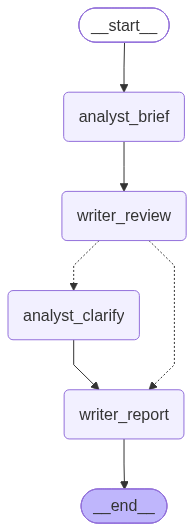

In [13]:
from IPython.display import Image
try:
    display(Image(pipeline.get_graph().draw_mermaid_png()))
except Exception:
    print(pipeline.get_graph().draw_ascii())

### 4.1 End-to-end run (one call, no manual steps). Persistent cache: first run is a MISS

In [14]:
from src.memory import research
t0 = time.time()
res1 = research("NVDA", pipeline=pipeline)
print(f"\nEnd-to-end time: {time.time()-t0:.0f}s | from cache: {res1['from_cache']}")

[CACHE MISS] no brief for NVDA on 2026-10-07 - running the agents

=== Agent A: Data Analyst ===


[Agent A: Data Analyst] ACTION  -> get_price_data({"period": "1y", "ticker": "NVDA"})


[Agent A: Data Analyst] OBSERVE <- get_price_data: {"ticker": "NVDA", "as_of": "2026-10-07", "period": "1y", "bars_in_period": 252, "current_price": 237.18, "period_return_pct": 28.48, "pct_change_30d": 5.19, "high_52w": 243.37, "low_52w": 163.9, "pct_from_52w_high": -2.54, "sma_50": 220.43, "sma_200": 201.35,...


[Agent A: Data Analyst] ACTION  -> calculate_volatility({"ticker": "NVDA", "window": 30})


[Agent A: Data Analyst] OBSERVE <- calculate_volatility: {"ticker": "NVDA", "window": 30, "as_of": "2026-10-07", "annualised_vol_pct": 37.25, "daily_vol_pct": 2.347, "downside_vol_pct": 20.9, "vol_percentile_1y": 40.0, "vol_1y_min_max_pct": [26.66, 47.44], "max_drawdown_1y_pct": -20.21, "expected_move_over_window_pc...


...

[Agent A: Data Analyst (answering clarification)] ACTION  -> llm_sentiment({"headlines": ["Enterprise AI Adoption and CoCo Agent Expansion Drive Snowflake’s (SNOW) Growth", "HSBC’s AI Push Comes for the Advisers", "Top Midday Stories: SpaceX Said to Seek $40 Billion in Finan)


[Agent A: Data Analyst (answering clarification)] OBSERVE <- llm_sentiment: {"score": 0.72, "label": "positive", "n_headlines": 5, "key_drivers": ["Enterprise AI adoption", "CoCo Agent expansion", "AI market growth", "Positive analyst sentiment"]}


[Agent A: Data Analyst (answering clarification)] THINK/SAY: **NVDA – Quantitative Snapshot (as of 2026‑10‑07)**    | Metric | Value | |--------|-------| | Annualised volatility (90‑day window) | **39.48 %** | | Daily volatility (90‑day window) | 2.487 % | | Downside volatility | 24.16 % | | 1‑year volatility percentile | 78 % | | 1‑year max drawdown | –20.21 % | | Sentiment score (last 7 days headlines) | **+0.72** (positive) |  **Interpretation**   - The ...



>>> HANDOFF data_analyst -> research_writer: ClarificationResponse
{
 "question": "Please compute a sentiment score for NVDA using the provided headlines over the last 7 days, and provide the annualised volatility over a 90\u2011day window (to use for hedge sizing).",
 "answer": "The requested quantitative snapshot for NVDA as of 2026\u201110\u201107 includes the 90\u2011day annualised volatility, daily volatility, downside volatility, 1\u2011year volatility percentile, 1\u2011year max drawdown, and the 7\u2011day sentiment score. These figures provide the basis for setting hedge parameters and assessing market sentiment.",
 "values": [
  {
   "name": "annualised_vol_pct_90d",
   "value": 39.48
  },
  {
   "name": "daily_vol_pct_90d",
   "value": 2.487
  },
  {
   "name": "downside_vol_pct_90d",
   "value": 24.16
  },
  {
   "name": "vol_percentile_1y",
   "value": 78.0
  },
  {
   "name": "max_drawdown_1y_pct",
   "value": -20.21
  },
  {
   "name": "sentiment_score_7d",
   "value": 


>>> HANDOFF research_writer -> user: FinalReport
{
 "ticker": "NVDA",
 "financial_health_summary": "NVDA trades above both its 50\u2011 and 200\u2011day moving averages, indicating a bullish trend. The 30\u2011day annualised volatility of 37.3\u202f% is below the 1\u2011year median (40\u202f%) and the 1\u2011year max drawdown is 20.2\u202f%. The 90\u2011day annualised volatility is 39.48\u202f%, slightly higher than the 30\u2011day figure, suggesting moderate short\u2011term risk. The 7\u2011day sentiment score of 0.72 reflects generally positive recent news, driven by strong AI\u2011infrastructure demand and favorable earnings outlook.",
 "market_sentiment": "Positive \u2013 recent earnings beat, AI demand, and a 7\u2011day sentiment score of 0.72.",
 "top_three_risks": [
  {
   "title": "Supply\u2011Chain Constraints",
   "evidence": "Semiconductor shortages could delay GPU shipments, as noted in analyst commentary on NVDA\u2019s competitive landscape.",
   "source": "NVDA Stock For

In [15]:
# The message trace: every handoff between agents, with typed payloads
hand = pd.DataFrame([{"#": i + 1, "from": h["from"], "to": h["to"], "type": h["type"],
                      "payload keys": ", ".join(list(h["payload"])[:8])} for i, h in enumerate(res1["handoffs"])])
display(hand)
from src.schemas import DataBrief
brief = DataBrief.model_validate(res1["brief"])           # the A -> B handoff is a validated object
print("DataBrief validated:", type(brief).__name__, "| data_gaps:", brief.data_gaps)
crit = [h for h in res1["handoffs"] if h["type"] in ("ClarificationRequest", "ClarificationResponse")]
print(f"Critique loop round-trips: {len([h for h in crit if h['type'] == 'ClarificationRequest'])}")
for h in crit:
    p = {k: v for k, v in h["payload"].items() if k != "headlines"}
    print(f"  {h['from']} -> {h['to']} [{h['type']}]: {json.dumps(p, ensure_ascii=False)[:400]}")

,#,from,to,type,payload keys
0,1,data_analyst,research_writer,DataBrief,"ticker, as_of, current_price, sma_50, sma_200, rsi_14, macd_histogram, pct_change_30d"
1,2,research_writer,data_analyst,ClarificationRequest,"question, field_needed, reason, headlines"
2,3,data_analyst,research_writer,ClarificationResponse,"question, answer, values, tools_used"
3,4,research_writer,user,FinalReport,"ticker, financial_health_summary, market_sentiment, top_three_risks, hedge_strategy, d..."


DataBrief validated: DataBrief | data_gaps: []
Critique loop round-trips: 1
  research_writer -> data_analyst [ClarificationRequest]: {"question": "Please compute a sentiment score for NVDA using the provided headlines over the last 7 days, and provide the annualised volatility over a 90‑day window (to use for hedge sizing).", "field_needed": "annualised volatility over a 90‑day window and sentiment score for NVDA", "reason": "The report requires a 90‑day volatility estimate to set hedge parameters and a sentiment score to gauge
  data_analyst -> research_writer [ClarificationResponse]: {"question": "Please compute a sentiment score for NVDA using the provided headlines over the last 7 days, and provide the annualised volatility over a 90‑day window (to use for hedge sizing).", "answer": "The requested quantitative snapshot for NVDA as of 2026‑10‑07 includes the 90‑day annualised volatility, daily volatility, downside volatility, 1‑year volatility percentile, 1‑year max drawdown,


In [16]:
# Which agent used which tool in this pipeline run (from the trace): no cross-over.
from src.observability.trace import read_trace
tr = pd.DataFrame([r for r in read_trace(res1["run_id"]) if r["event"] == "tool_call"])
display(pd.crosstab(tr["agent"], tr["tool"]))

tool,calculate_volatility,get_news,get_price_data,llm_sentiment,web_search
agent,,,,,
data_analyst,2,0,1,1,0
research_writer,0,1,0,0,2


In [17]:
from src.schemas import FinalReport
report = FinalReport.model_validate(res1["report"])
display(Markdown(report.to_markdown()))

# NVDA — Research Report

## Financial Health Summary
NVDA trades above both its 50‑ and 200‑day moving averages, indicating a bullish trend. The 30‑day annualised volatility of 37.3 % is below the 1‑year median (40 %) and the 1‑year max drawdown is 20.2 %. The 90‑day annualised volatility is 39.48 %, slightly higher than the 30‑day figure, suggesting moderate short‑term risk. The 7‑day sentiment score of 0.72 reflects generally positive recent news, driven by strong AI‑infrastructure demand and favorable earnings outlook.

**Market sentiment:** Positive – recent earnings beat, AI demand, and a 7‑day sentiment score of 0.72.

## Top Three Risks (next 90 days)
1. **Supply‑Chain Constraints** — Semiconductor shortages could delay GPU shipments, as noted in analyst commentary on NVDA’s competitive landscape. _(source: NVDA Stock Forecast, Price Targets & Analyst Ratings – AlgovestIQ)_
2. **Competitive Pressure** — AMD’s RDNA‑4 and Intel’s Xe‑HL are expected to erode market share in gaming and data‑center segments, per analyst notes. _(source: NVDA Stock Forecast, Price Targets & Analyst Ratings – AlgovestIQ)_
3. **Regulatory Scrutiny** — Potential antitrust investigations into NVIDIA’s recent acquisitions could impose fines or operational restrictions, highlighted in catalyst calendar and analyst reports. _(source: NVDA Catalyst Calendar – DocuRefinery)_

## Hedge Strategy Recommendation
**Buy a 90‑day protective put at 10 % out‑of‑the‑money (strike ≈ 213.46, 90‑day vol 39.48 %)**

- *Rationale:* The 90‑day annualised volatility of 39.48 % justifies a 10 % OTM strike to balance protection with cost. The positive sentiment score (0.72) and bullish trend reduce the need for a deeper hedge, while the identified risks (supply‑chain, competition, regulation) warrant downside protection.
- *Parameters:* Strike 213.46 (10 % OTM), tenor 90 days, size 1 % of portfolio (based on 90‑day vol and 7‑day sentiment)
- *Trade-offs:* Higher cost than a 5 % OTM put; limited protection if volatility spikes beyond 90‑day average; requires monitoring of earnings and regulatory developments.

**Data limitations:**
- none reported


## 5. Task 3C (part 2) — Persistent cache: the second run is a HIT
The same call again loads `cache/NVDA_<date>.json`. No agent runs and no tool is called, as the trace for the
run confirms.

In [18]:
t0 = time.time()
res2 = research("NVDA", pipeline=pipeline)
calls2 = [r for r in read_trace(res2["run_id"]) if r["event"] == "tool_call"]
print(f"from cache: {res2['from_cache']} | time: {time.time()-t0:.2f}s | tool calls in this run: {len(calls2)}")
print("cached file:", cache_path("NVDA").relative_to(config.PROJECT_DIR))
assert res2["report"] == res1["report"]

[CACHE HIT] NVDA_2026-10-07.json - loaded the saved brief, skipping all agents and tool calls
from cache: True | time: 0.02s | tool calls in this run: 0
cached file: cache\NVDA_2026-10-07.json


## 6. Observability — `logs/agent_trace.jsonl`
Every tool call is logged with its **tool name, inputs, output (truncated to 200 chars) and wall-clock duration**,
plus the calling agent, run id, status and timestamp. Handoffs and cache hits are logged as events too.

In [19]:
trace = pd.DataFrame(read_trace())
print("events:", len(trace), "| tool calls:", int((trace.event == "tool_call").sum()),
      "| errors:", int((trace.status == "error").sum()), "| file:", config.TRACE_PATH.relative_to(config.PROJECT_DIR))
print("\nFirst 3 lines of the file:")
with open(config.TRACE_PATH, encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().strip()[:400])
calls = trace[trace.event == "tool_call"]
display(calls.groupby("tool").agg(calls=("tool", "size"), mean_ms=("duration_ms", "mean"),
                                  errors=("status", lambda s: int((s != "ok").sum()))).round(1))
display(pd.crosstab(calls["run_id"], calls["tool"]))

events: 39 | tool calls: 28 | errors: 6 | file: logs\agent_trace.jsonl

First 3 lines of the file:
{"event": "tool_call", "tool": "get_price_data", "inputs": {"args": [], "kwargs": {"ticker": "NVDA", "period": "1y"}}, "output": "{\"ticker\": \"NVDA\", \"as_of\": \"2026-10-07\", \"period\": \"1y\", \"bars_in_period\": 252, \"current_price\": 237.26, \"period_return_pct\": 28.53, \"pct_change_30d\": 5.23, \"high_52w\": 243.37, \"low_52w\": 163.9, \"pct", "status": "ok", "duration_ms": 1527.9, "ts
{"event": "tool_call", "tool": "calculate_volatility", "inputs": {"args": [], "kwargs": {"ticker": "NVDA", "window": 30}}, "output": "{\"ticker\": \"NVDA\", \"window\": 30, \"as_of\": \"2026-10-07\", \"annualised_vol_pct\": 37.24, \"daily_vol_pct\": 2.346, \"downside_vol_pct\": 20.94, \"vol_percentile_1y\": 40.0, \"vol_1y_min_max_pct\": [26.66, 47.44],", "status": "ok", "duration_ms": 194.5, "ts":
{"event": "tool_call", "tool": "get_news", "inputs": {"args": [], "kwargs": {"ticker": "NVDA", "n":

,calls,mean_ms,errors
tool,,,
calculate_volatility,6,892.6,1
get_news,5,2485.1,2
get_price_data,6,2186.8,2
llm_sentiment,5,937.1,1
web_search,6,7243.2,0


tool,calculate_volatility,get_news,get_price_data,llm_sentiment,web_search
run_id,,,,,
3A-0cf51d12,1,1,1,1,0
3A-1409581b,0,0,1,0,1
3A-77512fee,1,1,1,1,2
3B-5711b3ea,2,1,1,1,2
demo-04694e0c,2,2,2,2,1


## 7. Bonus — Streamlit dashboard over the trace
`streamlit run dashboard.py` opens an interactive view with per-run filters, KPIs, a timeline, latency by tool,
an agent × tool matrix and error/handoff tables. Below, the app is executed headlessly with Streamlit's
`AppTest` to show it runs on this trace file. A static preview of the same views is rendered with matplotlib.

In [20]:
from streamlit.testing.v1 import AppTest
at = AppTest.from_file("dashboard.py", default_timeout=60).run()
print("dashboard ran without exceptions:", not at.exception)
print("metrics:", {m.label: m.value for m in at.metric})
print("sections:", [h.value for h in at.subheader])

2026-10-07 21:44:13.070 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


dashboard ran without exceptions: True
metrics: {'Tool calls': '28', 'Total tool time (s)': '79.05', 'Errors': '6', 'Runs': '7'}
sections: ['Timeline', 'Mean latency by tool (ms)', 'Agent x tool (call counts)', 'Errors', 'Handoffs and other events', 'Raw tool calls']


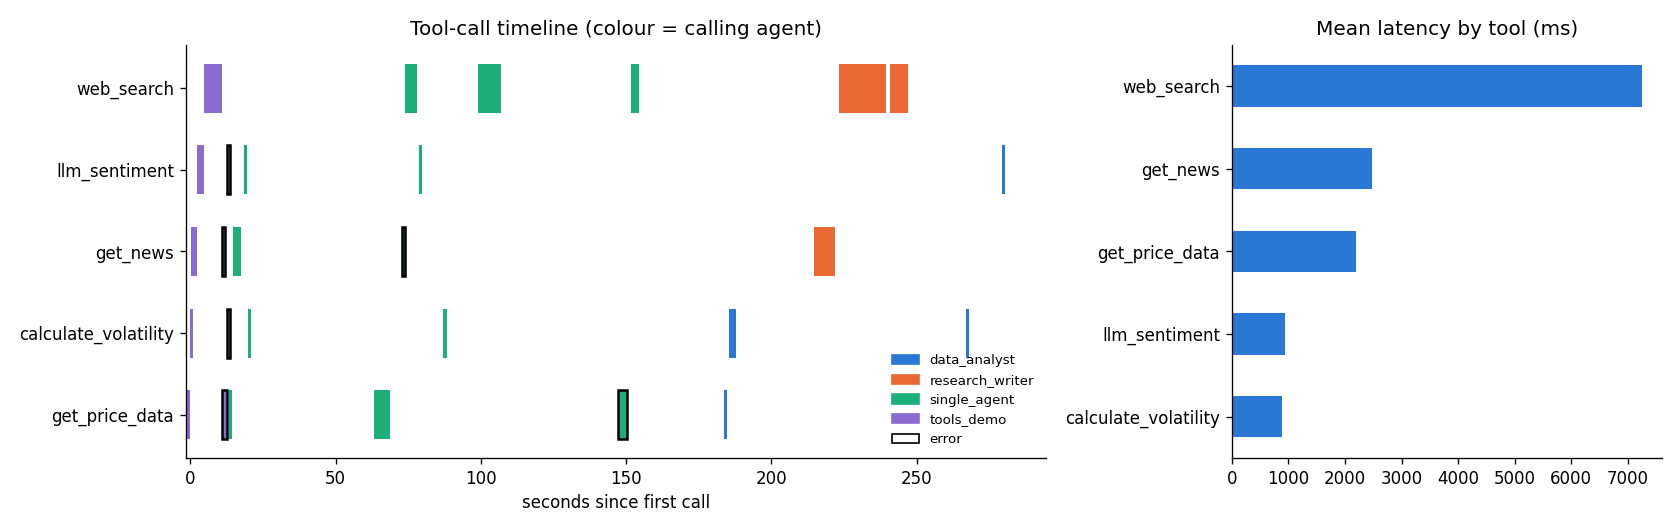

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
c = calls.copy(); c["ts"] = pd.to_datetime(c["ts"])
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#8a6bd1", "#a3a29c"]
colors = {a: palette[i % len(palette)] for i, a in enumerate(sorted(c["agent"].unique()))}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [2, 1]})
t0 = c["ts"].min()
for _, r in c.sort_values("ts").iterrows():
    start = (r["ts"] - t0).total_seconds() - r["duration_ms"] / 1000
    axes[0].barh(r["tool"], max(r["duration_ms"] / 1000, 1.0), left=start, height=0.6,
                 color=colors[r["agent"]], edgecolor="black" if r["status"] != "ok" else "none", linewidth=1.5)
axes[0].legend(handles=[Patch(color=col, label=a) for a, col in colors.items()]
               + [Patch(facecolor="white", edgecolor="black", label="error")],
               frameon=False, fontsize=8, loc="lower right")
axes[0].set(title="Tool-call timeline (colour = calling agent)", xlabel="seconds since first call")
c.groupby("tool")["duration_ms"].mean().sort_values().plot.barh(ax=axes[1], color="#2a78d6")
axes[1].set(title="Mean latency by tool (ms)", ylabel="")
for ax in axes:
    for side in ("top", "right"): ax.spines[side].set_visible(False)
fig.tight_layout(); fig.savefig(config.OUTPUT_DIR / "trace_dashboard_preview.png", dpi=120); plt.close(fig)
display(Image(filename=str(config.OUTPUT_DIR / "trace_dashboard_preview.png")))

In [22]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
                   capture_output=True, text=True)
print(r.stdout[-400:])

........                                                                 [100%]
8 passed in 1.44s

